# Import necessary libraries

In [ ]:
# Importing essential libraries
import pandas as pd  # for data manipulation
import numpy as np   # for numerical operations
import matplotlib.pyplot as plt  # for visualization
import seaborn as sns  # for enhanced visualizations
import os  # for operating system interactions
import shutil  # for high-level file operations
import kagglehub  # for downloading datasets from Kaggle
import zipfile  # for handling zip files
import warnings  # for managing warning messages
from sklearn.preprocessing import MinMaxScaler # for scaling data
from sklearn.preprocessing import StandardScaler # for scaling data
from sklearn.decomposition import PCA  # for PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis  # for LDA
from sklearn.manifold import TSNE  # for t-SNE
!pip install kmeans # for K-means clustering
!pip install kmedoids  # for K-medoids clustering
!pip install kmodes  # for K-modes clustering
!pip install scikit-learn-extra  # for extra functionalities in scikit-learn
from sklearn.cluster import KMeans  # for K-means clustering - Import KMeans from sklearn.cluster
from kmedoids import KMedoids # import Kmedoids directly from kmedoids
from kmodes.kmodes import KModes  # import KModes directly from kmodes
from sklearn.metrics import silhouette_score  # for silhouette score
import scipy.cluster.hierarchy as sch  # for hierarchical clustering
from sklearn.cluster import DBSCAN  # for DBSCAN clustering
from sklearn.mixture import GaussianMixture  # for GMM clustering
from sklearn.preprocessing import OneHotEncoder  # for encoding
from sklearn.metrics import pairwise_distances  # for pairwise distances
from scipy.spatial.distance import mahalanobis, chebyshev # for other distances

# General setup for visualizations
%matplotlib inline
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# Extract the zip file

In [ ]:
# Install Kaggle if not already installed
!pip install kaggle

# Set up Kaggle API credentials (ensure you have uploaded kaggle.json to your Colab environment)
os.environ['KAGGLE_CONFIG_DIR'] = "/content/"  # Adjust if needed based on where you placed kaggle.json

# Download the dataset using the Kaggle API
!kaggle datasets download -d rajanand/crime-in-india

# Unzip the downloaded file
with zipfile.ZipFile('crime-in-india.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/Crime_in_India_Dataset')

# Directory containing the extracted CSV files
data_dir = '/content/Crime_in_India_Dataset'  # Adjust this if needed
output_dir = '/content/Consolidated_Crime_Data'  # Directory to store consolidated CSV files

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# List all CSV files in the directory and its subdirectories
for root, dirs, files in os.walk(data_dir):
    for file in files:
        if file.endswith('.csv'):
            # Construct full file path
            file_path = os.path.join(root, file)
            # Copy the file to the output directory
            shutil.copy(file_path, os.path.join(output_dir, file))

print(f"All CSV files have been consolidated into: {output_dir}")


Dataset URL: https://www.kaggle.com/datasets/rajanand/crime-in-india
License(s): CC-BY-SA-4.0
crime-in-india.zip: Skipping, found more recently modified local copy (use --force to force download)
All CSV files have been consolidated into: /content/Consolidated_Crime_Data


# Load all the data files

In [ ]:
# Directory containing the consolidated CSV files
data_dir = '/content/Consolidated_Crime_Data'  # Adjust this if needed

# Dictionary to hold DataFrames for each CSV file
dataframes = {}

# Load all CSV files into DataFrames
for file in os.listdir(data_dir):
    if file.endswith('.csv'):
        file_path = os.path.join(data_dir, file)
        try:
            # Use on_bad_lines='skip' to skip lines with too many or too few fields
            dataframes[file] = pd.read_csv(file_path, on_bad_lines='skip')
        except Exception as e:
            print(f"Error loading {file}: {e}")

# Check the names of the loaded DataFrames
print("Loaded DataFrames:", dataframes.keys())


Loaded DataFrames: dict_keys(['18_03_Juveniles_arrested_Family_background.csv', '08_02_Juvenile_apprehended_state_SLL.csv', '09_Juveniles_arrested_and_their_disposal.csv', '11_Property_stolen_and_recovered_nature_of_property.csv', '28_Trial_of_violent_crimes_by_courts.csv', '42_Cases_under_crime_against_women.csv', '07_01_Persons_arrested_by_sex_and_age_group_IPC_2014.csv', '18_04_Juveniles_arrested_Recidivism.csv', '17_Crime_by_place_of_occurrence_2014.csv', '13_Police_killed_or_injured_on_duty.csv', '02_District_wise_crimes_committed_against_ST_2001_2012.csv', '04_01_Person_arrested_and_their_disposal_by_police_and_court_SLL_crime_2012.csv', '17_Case_reported_and_value_of_property_taken_away_by_place_of_occurrence_2001_2012.csv', '31_Serious_fraud.csv', '40_04_Custodial_death_during_hospitalization_or_treatment.csv', '07_02_Persons_arrested_by_sex_and_age_group_SLL_2013.csv', '15_Police_natural_death_and_suicide.csv', '04_02_Person_arrested_and_their_disposal_by_police_and_court_IPC_

# Clean all the data files

In [ ]:
# Directory containing the consolidated CSV files
data_dir = '/content/Consolidated_Crime_Data'  # Adjust this if needed

# Dictionary to hold DataFrames for each CSV file
dataframes = {}

# Load all CSV files into DataFrames
for file in os.listdir(data_dir):
    if file.endswith('.csv'):
        file_path = os.path.join(data_dir, file)
        try:
            # Use on_bad_lines='skip' to skip lines with too many or too few fields
            dataframes[file] = pd.read_csv(file_path, on_bad_lines='skip')
        except Exception as e:
            print(f"Error loading {file}: {e}")

# Clean all DataFrames by dropping rows with NaN values
for file, df in dataframes.items():
    dataframes[file] = df.dropna()

# Check the names of the cleaned DataFrames and their shapes
for file, df in dataframes.items():
    print(f"{file}: {df.shape} (after cleaning)")


18_03_Juveniles_arrested_Family_background.csv: (350, 7) (after cleaning)
08_02_Juvenile_apprehended_state_SLL.csv: (9450, 12) (after cleaning)
09_Juveniles_arrested_and_their_disposal.csv: (349, 10) (after cleaning)
11_Property_stolen_and_recovered_nature_of_property.csv: (4550, 8) (after cleaning)
28_Trial_of_violent_crimes_by_courts.csv: (3138, 7) (after cleaning)
42_Cases_under_crime_against_women.csv: (2765, 22) (after cleaning)
07_01_Persons_arrested_by_sex_and_age_group_IPC_2014.csv: (3432, 18) (after cleaning)
18_04_Juveniles_arrested_Recidivism.csv: (350, 6) (after cleaning)
17_Crime_by_place_of_occurrence_2014.csv: (39, 82) (after cleaning)
13_Police_killed_or_injured_on_duty.csv: (2450, 18) (after cleaning)
02_District_wise_crimes_committed_against_ST_2001_2012.csv: (9018, 13) (after cleaning)
04_01_Person_arrested_and_their_disposal_by_police_and_court_SLL_crime_2012.csv: (1025, 14) (after cleaning)
17_Case_reported_and_value_of_property_taken_away_by_place_of_occurrence_20

# Normalize all the data files

In [ ]:
# Create a MinMaxScaler instance
scaler = MinMaxScaler()

# Normalize all DataFrames
for file, df in dataframes.items():
    # Identify numerical columns
    numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

    # Normalize numerical columns
    df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

    # Update the DataFrame in the dictionary
    dataframes[file] = df

# Check the normalized DataFrames and their first few rows
for file, df in dataframes.items():
    print(f"{file} (normalized):\n", df.head(), "\n")

18_03_Juveniles_arrested_Family_background.csv (normalized):
                    Area_Name  Year        Sub_Group_Name  \
0  Andaman & Nicobar Islands   0.0  3. Family Background   
1             Andhra Pradesh   0.0  3. Family Background   
2          Arunachal Pradesh   0.0  3. Family Background   
3                      Assam   0.0  3. Family Background   
4                      Bihar   0.0  3. Family Background   

   Family_back_ground_Homeless  Family_back_ground_Living_with_guardian  \
0                     0.000000                                 0.000000   
1                     0.563265                                 0.123176   
2                     0.000000                                 0.024893   
3                     0.021429                                 0.031760   
4                     0.043878                                 0.043348   

   Family_back_ground_Living_with_parents  Family_back_ground_Total  
0                                0.002459               

# Bar Graphs

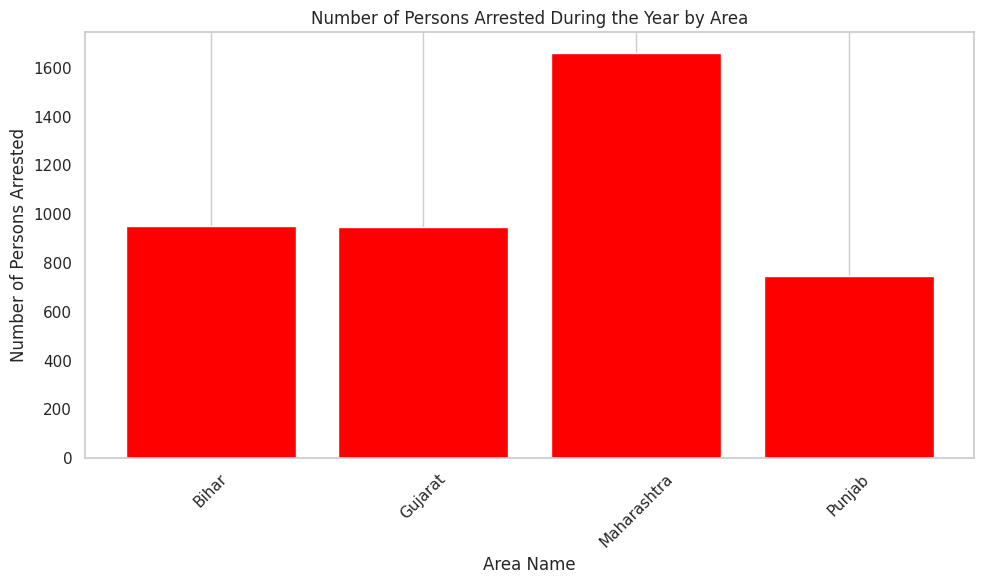

In [ ]:
# Load the specific CSV file
file_path = '/content/Consolidated_Crime_Data/07_01_Persons_arrested_by_sex_and_age_group_IPC_2013.csv'
df_arrested = pd.read_csv(file_path)

data = {
    'Area_Name': ['Bihar', 'Gujarat', 'Maharashtra', 'Maharashtra', 'Punjab'],
    'Year': [2007, 2010, 2007, 2003, 2005],
    'ACA02_No_of_persons_arrested_during_the_year': [950.0, 947.0, 870.0, 792.0, 748.0]
}
df_arrested = pd.DataFrame(data)

# Grouping data by Area_Name and summing the number of arrests
grouped_data = df_arrested.groupby('Area_Name')['ACA02_No_of_persons_arrested_during_the_year'].sum().reset_index()

# Creating the bar graph
plt.figure(figsize=(10, 6))
plt.bar(grouped_data['Area_Name'], grouped_data['ACA02_No_of_persons_arrested_during_the_year'], color='red')
plt.title('Number of Persons Arrested During the Year by Area')
plt.xlabel('Area Name')
plt.ylabel('Number of Persons Arrested')
plt.xticks(rotation=45)
plt.grid(axis='y')

# Show the plot
plt.tight_layout()
plt.show()

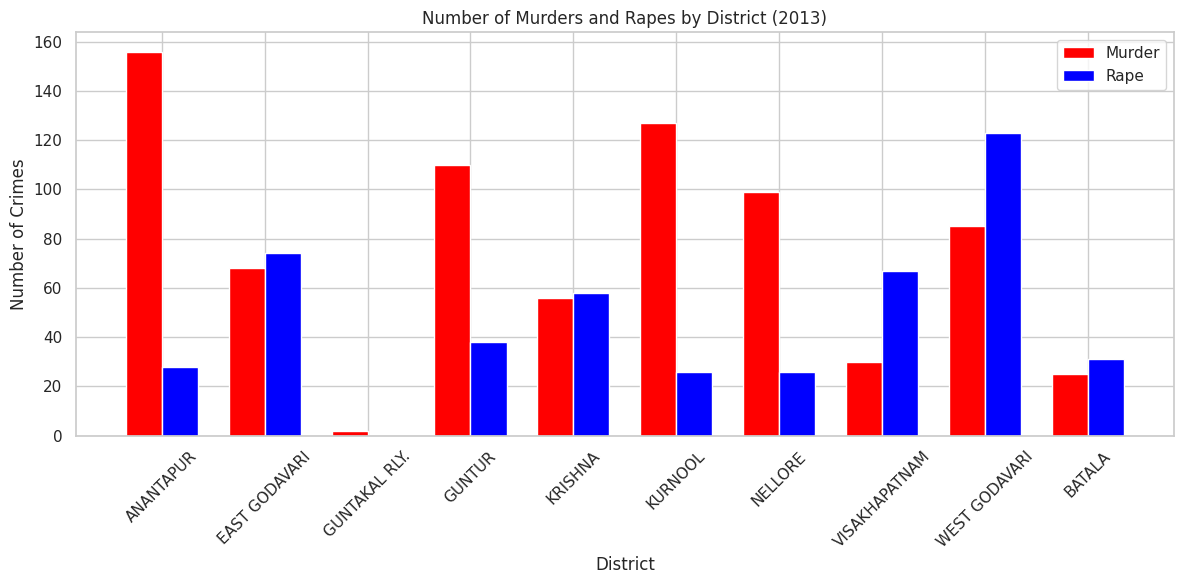

In [ ]:
# Load the specific CSV file
file_path = '/content/Consolidated_Crime_Data/01_District_wise_crimes_committed_IPC_2013.csv'
df_crimes_2013 = pd.read_csv(file_path)

limited_districts = [
    'ANANTAPUR',
    'EAST GODAVARI',
    'BATALA',
    'GUNTAKAL RLY.',  # Adjust this if needed
    'VISAKHAPATNAM',
    'KRISHNA',
    'GUNTUR',
    'KURNOOL',
    'NELLORE',
    'WEST GODAVARI'
]

# Limit the DataFrame to the specific set of districts for visualization
df_crimes_2013_limited = df_crimes_2013[df_crimes_2013['DISTRICT'].isin(limited_districts)]

# Check if the necessary columns exist in the limited DataFrame
if 'MURDER' not in df_crimes_2013_limited.columns or 'RAPE' not in df_crimes_2013_limited.columns:
    print("MURDER or RAPE columns not found in the DataFrame.")
else:
    # Define the columns to use for the bar graph
    district_column = 'DISTRICT'  # Column for districts
    murder_column = 'MURDER'       # Column name for murder counts
    rape_column = 'RAPE'           # Column name for rape counts

    # Fill missing values with 0 for the necessary columns
    df_crimes_2013_limited[murder_column] = df_crimes_2013_limited[murder_column].fillna(0)
    df_crimes_2013_limited[rape_column] = df_crimes_2013_limited[rape_column].fillna(0)

    # Create a bar graph for murders and rapes
    plt.figure(figsize=(12, 6))
    bar_width = 0.35
    x = np.arange(len(df_crimes_2013_limited[district_column]))

    # Create bars for murders and rapes
    plt.bar(x - bar_width / 2, df_crimes_2013_limited[murder_column], width=bar_width, label='Murder', color='red')
    plt.bar(x + bar_width / 2, df_crimes_2013_limited[rape_column], width=bar_width, label='Rape', color='blue')

    # Customize the plot
    plt.xlabel('District')
    plt.ylabel('Number of Crimes')
    plt.title('Number of Murders and Rapes by District (2013)')
    plt.xticks(x, df_crimes_2013_limited[district_column], rotation=45)  # Rotate labels for better visibility
    plt.legend()
    plt.tight_layout()  # Adjust layout to make room for x-axis labels
    plt.show()


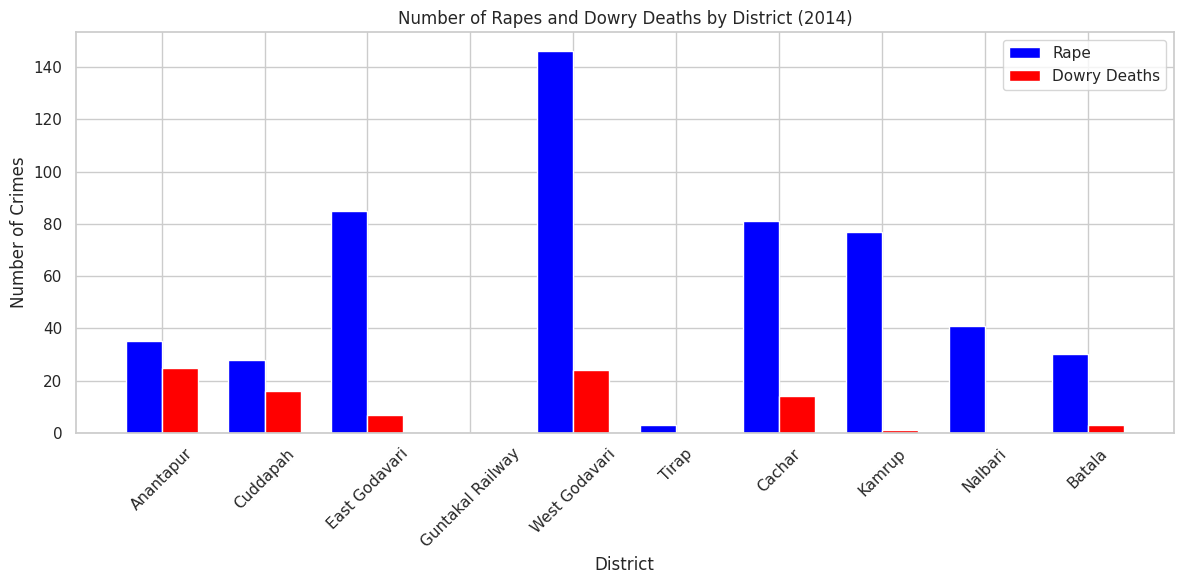

In [ ]:
# Load the specific CSV file
file_path = '/content/Consolidated_Crime_Data/42_District_wise_crimes_committed_against_women_2014.csv'
df_crimes_again = pd.read_csv(file_path)

# Define the columns to use for the bar graph
district_column = 'District'  # Corrected column name
rape_column = 'Rape'           # Corrected column name
dowry_deaths_column = 'Dowry Deaths'  # Corrected column name

# Specify the districts to include in the graph
desired_districts = [
    'Guntakal Railway',
    'Anantapur',
    'East Godavari',  # Replace with actual district names
    'West Godavari',  # Replace with actual district names
    'Cuddapah',  # Replace with actual district names
    'Cachar',  # Replace with actual district names
    'Nalbari',  # Replace with actual district names
    'Batala',  # Replace with actual district names
    'Kamrup',  # Replace with actual district names
    'Tirap'   # Replace with actual district names
]

# Filter the DataFrame to include only the desired districts
df_filtered = df_crimes_again[df_crimes_again[district_column].isin(desired_districts)]

# Create a bar graph for rapes and dowry deaths
plt.figure(figsize=(12, 6))
bar_width = 0.35
x = np.arange(len(df_filtered))

# Create bars for rapes and dowry deaths
plt.bar(x - bar_width/2, df_filtered[rape_column], width=bar_width, label='Rape', color='blue')
plt.bar(x + bar_width/2, df_filtered[dowry_deaths_column], width=bar_width, label='Dowry Deaths', color='red')

# Customize the plot
plt.xlabel('District')
plt.ylabel('Number of Crimes')
plt.title('Number of Rapes and Dowry Deaths by District (2014)')
plt.xticks(x, df_filtered[district_column], rotation=45)
plt.legend()
plt.tight_layout()  # Adjust layout to make room for x-axis labels
plt.show()


# Line Graph

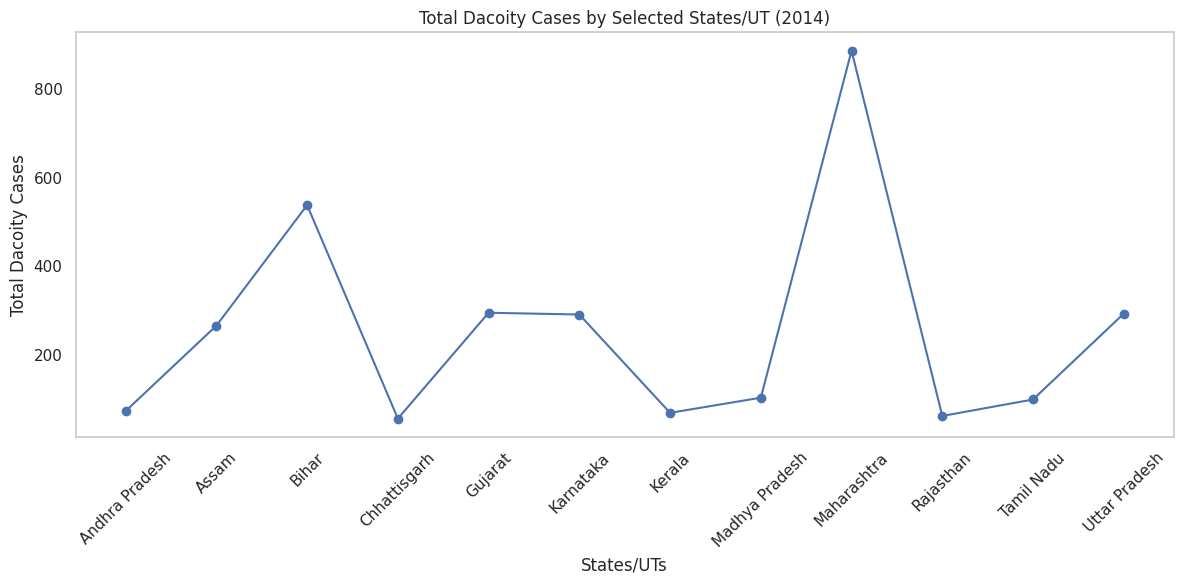

In [ ]:
# Load the specific CSV file
file_path = '/content/Consolidated_Crime_Data/17_Crime_by_place_of_occurrence_2014.csv'
df_crime_by_place = pd.read_csv(file_path)

# Define the states/UTs you want to include (13 in this example)
selected_states = [
    'Andhra Pradesh',
    'Bihar',
    'Assam',
    'Chhattisgarh',
    'Delhi',
    'Gujarat',
    'Karnataka',
    'Kerala',
    'Madhya Pradesh',
    'Maharashtra',
    'Rajasthan',
    'Tamil Nadu',
    'Uttar Pradesh'
]

# Filter the DataFrame for the selected states
df_filtered = df_crime_by_place[df_crime_by_place['States/UTs'].isin(selected_states)]

# Define columns for plotting
state_column = 'States/UTs'  # Column for states/UTs
dacoity_cases_column = 'Total_Dacoity_Cases reported'  # Column for total dacoity cases

# Create a line graph for total dacoity cases by state
plt.figure(figsize=(12, 6))

# Plotting the line graph
plt.plot(df_filtered[state_column], df_filtered[dacoity_cases_column], marker='o')

# Customize the plot
plt.xlabel('States/UTs')
plt.ylabel('Total Dacoity Cases')
plt.title('Total Dacoity Cases by Selected States/UT (2014)')
plt.xticks(rotation=45)
plt.tight_layout()  # Adjust layout to make room for x-axis labels
plt.grid()  # Optional: Add grid lines for better readability
plt.show()


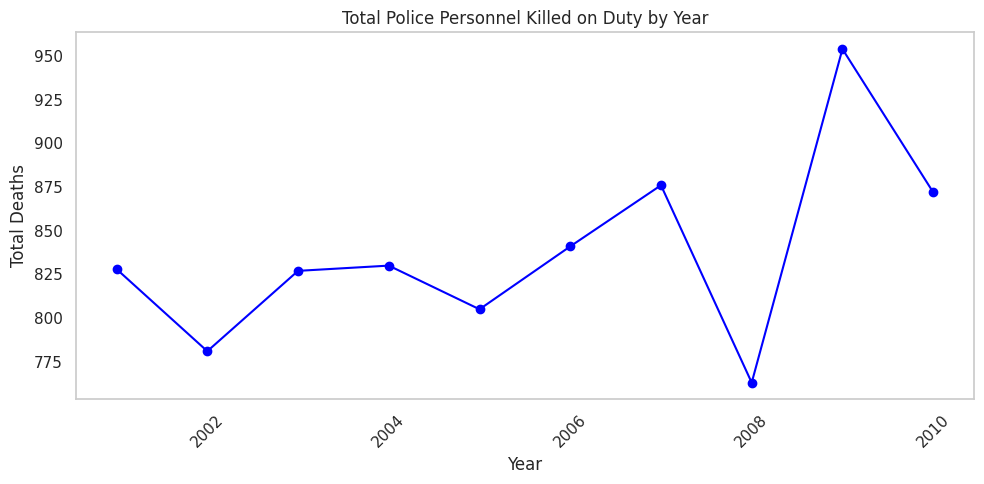

In [ ]:
# Load the specific CSV file
file_path = '/content/Consolidated_Crime_Data/14_Age_profile_of_police_personnel_killed_on_duty.csv'
df_age_profile = pd.read_csv(file_path)

# Group by year and sum the total deaths
df_yearly_totals = df_age_profile.groupby('Year').sum(numeric_only=True).reset_index()

# Create a line graph for total deaths over the years
plt.figure(figsize=(10, 5))
plt.plot(df_yearly_totals['Year'], df_yearly_totals['Age_Total'], marker='o', color='blue')

# Customize the plot
plt.xlabel('Year')
plt.ylabel('Total Deaths')
plt.title('Total Police Personnel Killed on Duty by Year')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()  # Adjust layout to make room for x-axis labels
plt.show()


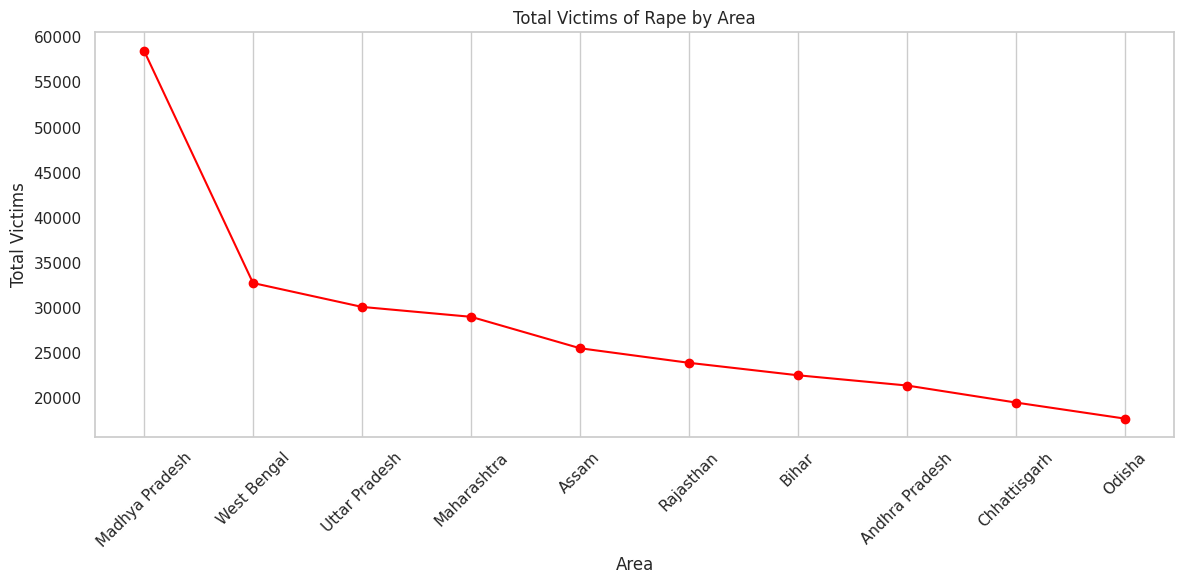

In [ ]:
# Load the specific CSV file
file_path = '/content/Consolidated_Crime_Data/20_Victims_of_rape.csv'
df_rape_victims = pd.read_csv(file_path)

# Group by area and sum the total number of victims (assuming we want total victims across all subgroups)
df_area_victims = df_rape_victims.groupby('Area_Name').sum(numeric_only=True).reset_index()

# Filter for the top 10 areas with the highest number of total rape victims
top_areas_victims = df_area_victims.nlargest(10, 'Victims_of_Rape_Total')

# Create a line graph for total victims by area
plt.figure(figsize=(12, 6))
plt.plot(top_areas_victims['Area_Name'], top_areas_victims['Victims_of_Rape_Total'], marker='o', color='red')
plt.title('Total Victims of Rape by Area')
plt.xlabel('Area')
plt.ylabel('Total Victims')
plt.xticks(rotation=45)
plt.grid(axis='y')

# Show the plot
plt.tight_layout()
plt.show()


# Scatter Plot

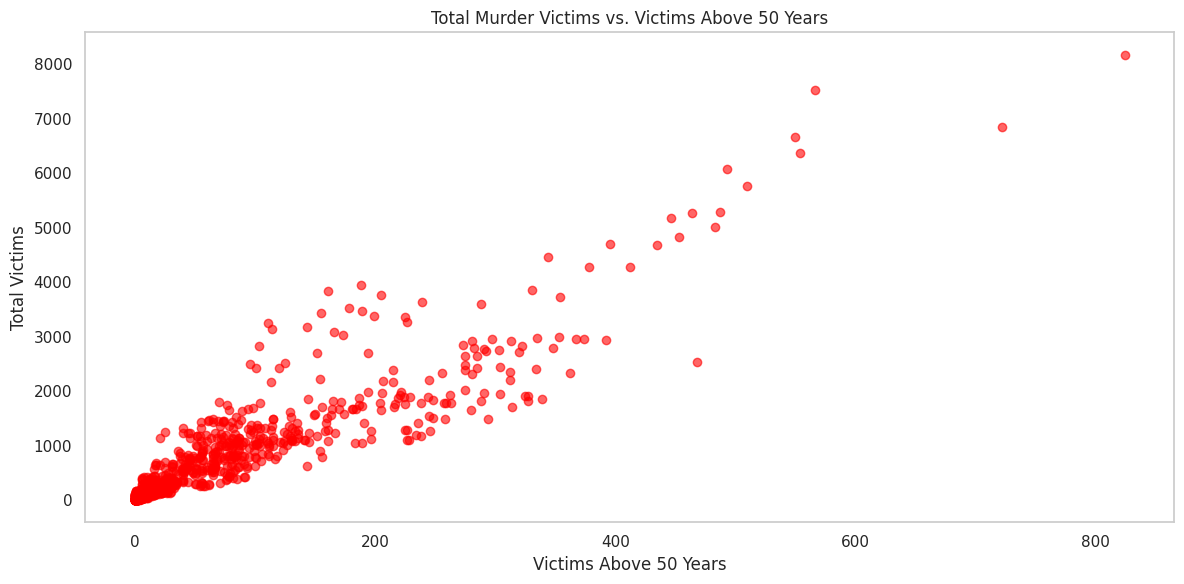

In [ ]:
# Load the specific CSV file
file_path = '/content/Consolidated_Crime_Data/32_Murder_victim_age_sex.csv'
df_murder_victims = pd.read_csv(file_path)

# Remove rows with NaN values in the relevant columns
df_murder_victims = df_murder_victims.dropna(subset=['Victims_Total', 'Victims_Above_50_Yrs'])

# Create a scatter plot for victims above 50 years vs. total victims
plt.figure(figsize=(12, 6))
plt.scatter(df_murder_victims['Victims_Above_50_Yrs'], df_murder_victims['Victims_Total'], color='red', alpha=0.6)
plt.title('Total Murder Victims vs. Victims Above 50 Years')
plt.xlabel('Victims Above 50 Years')
plt.ylabel('Total Victims')
plt.grid()

# Show the plot
plt.tight_layout()
plt.show()


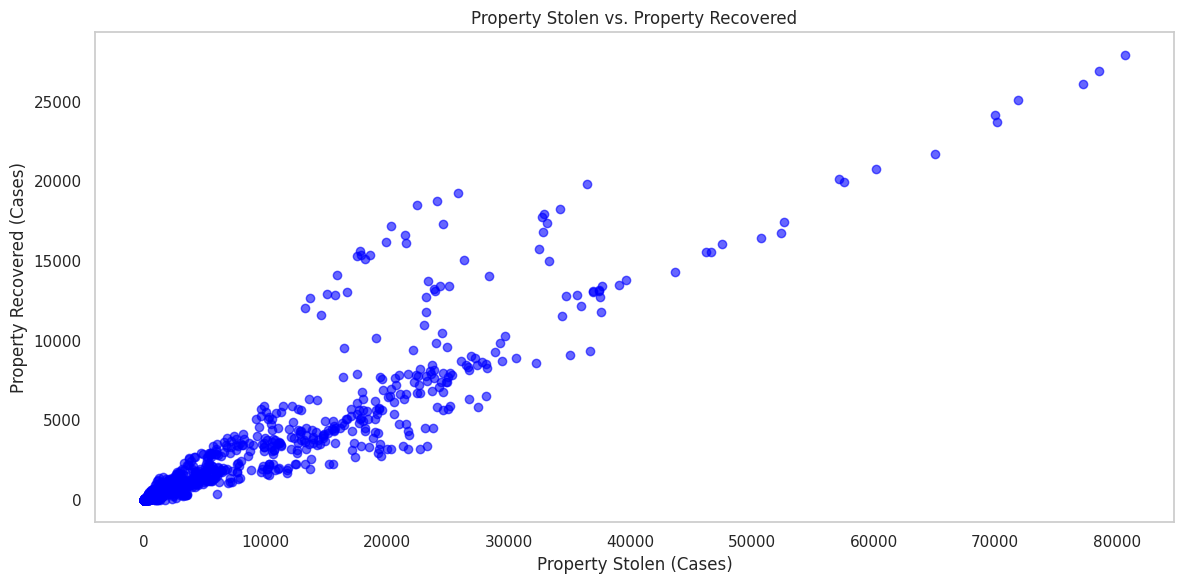

In [ ]:
# Load the specific CSV file
file_path = '/content/Consolidated_Crime_Data/10_Property_stolen_and_recovered.csv'
df_property = pd.read_csv(file_path)

# Remove rows with NaN values in the relevant columns
# Using the correct column names for property stolen and recovered
df_property = df_property.dropna(subset=['Cases_Property_Stolen', 'Cases_Property_Recovered'])

# Create a scatter plot for property stolen vs. property recovered
plt.figure(figsize=(12, 6))
plt.scatter(df_property['Cases_Property_Stolen'], df_property['Cases_Property_Recovered'], color='blue', alpha=0.6)
plt.title('Property Stolen vs. Property Recovered')
plt.xlabel('Property Stolen (Cases)')
plt.ylabel('Property Recovered (Cases)')
plt.grid()

# Show the plot
plt.tight_layout()
plt.show()


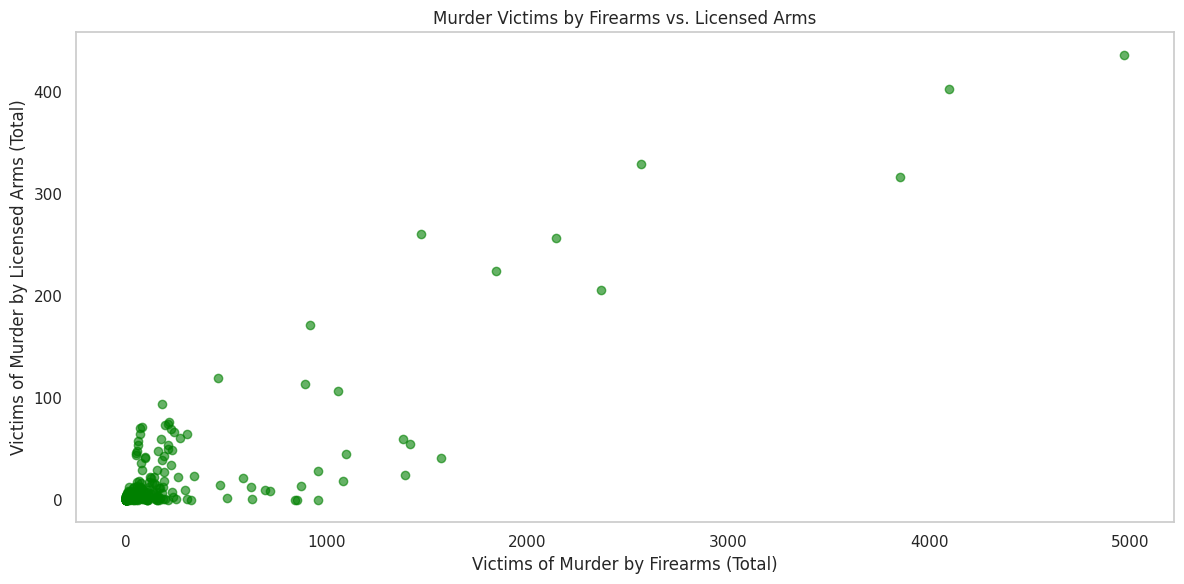

In [ ]:
# Load the specific CSV file
file_path = '/content/Consolidated_Crime_Data/34_Use_of_fire_arms_in_murder_cases.csv'
df_firearms = pd.read_csv(file_path)

# Remove rows with NaN values in the relevant columns
df_firearms = df_firearms.dropna(subset=['Victims_of_Murder_by_Fire_arms', 'Victims_of_Murder_by_Licensed_arms'])

# Create a scatter plot for murder victims by firearms vs. licensed arms
plt.figure(figsize=(12, 6))
plt.scatter(df_firearms['Victims_of_Murder_by_Fire_arms'], df_firearms['Victims_of_Murder_by_Licensed_arms'], color='green', alpha=0.6)
plt.title('Murder Victims by Firearms vs. Licensed Arms')
plt.xlabel('Victims of Murder by Firearms (Total)')
plt.ylabel('Victims of Murder by Licensed Arms (Total)')
plt.grid()

# Show the plot
plt.tight_layout()
plt.show()


# Histogram

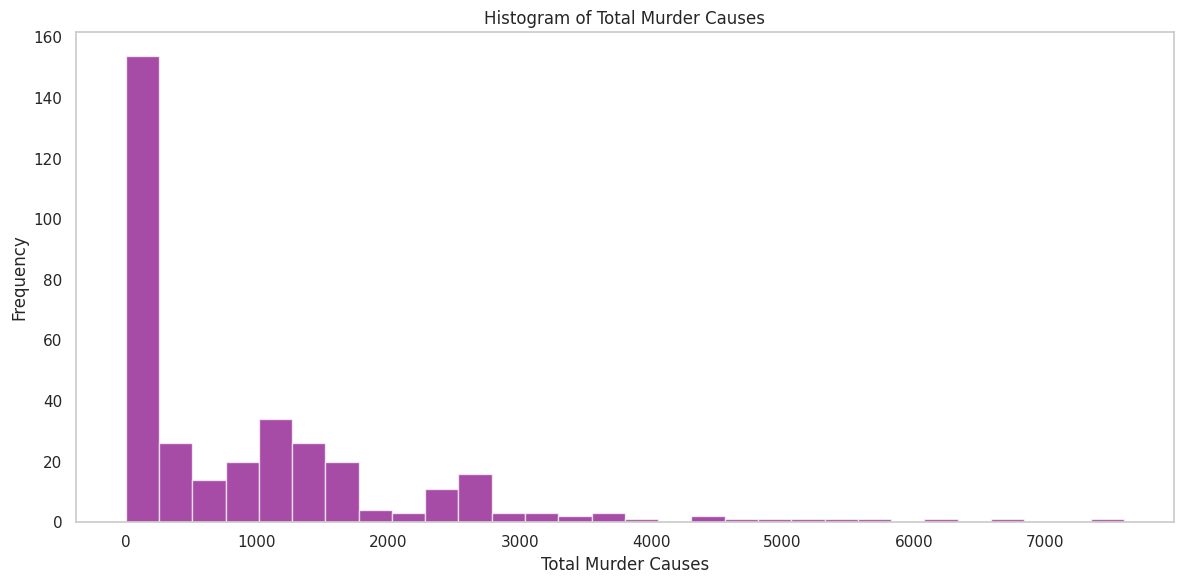

In [ ]:
# Load the specific CSV file
file_path = '/content/Consolidated_Crime_Data/19_Motive_or_cause_of_murder_and_culpable_homicide_not_amounting_to_murder.csv'
df_motive = pd.read_csv(file_path)

# Remove rows with NaN values in the relevant column
df_motive = df_motive.dropna(subset=['Murder_Cause_Total'])  # Using the actual column name

# Create a histogram for the chosen column
plt.figure(figsize=(12, 6))
plt.hist(df_motive['Murder_Cause_Total'], bins=30, color='purple', alpha=0.7)
plt.title('Histogram of Total Murder Causes')
plt.xlabel('Total Murder Causes')
plt.ylabel('Frequency')
plt.grid()

# Show the plot
plt.tight_layout()
plt.show()


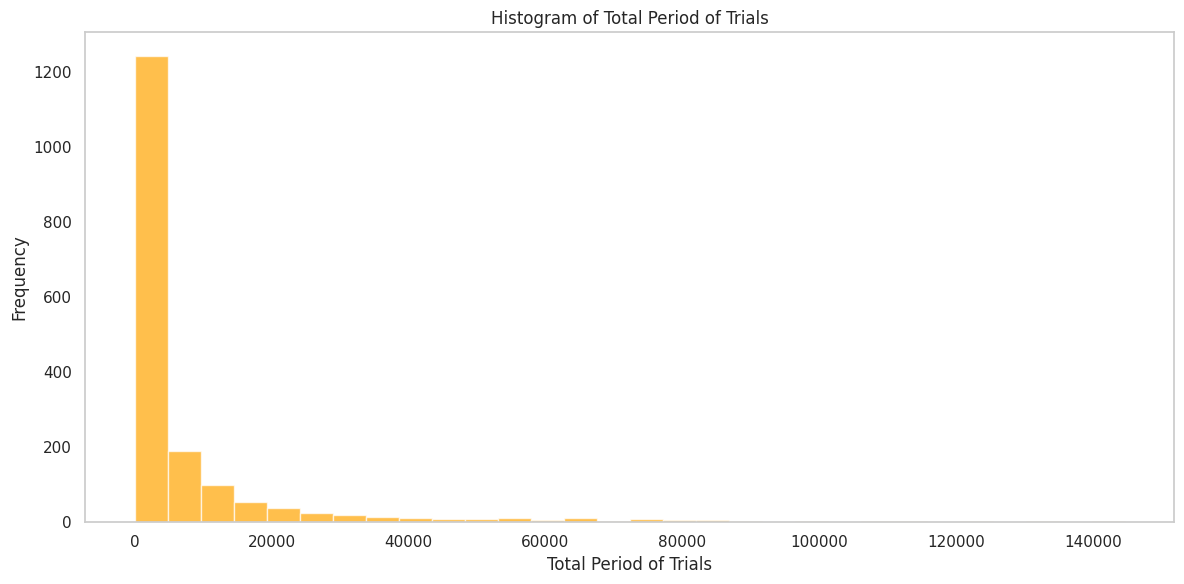

In [ ]:
# Load the specific CSV file
file_path = '/content/Consolidated_Crime_Data/29_Period_of_trials_by_courts.csv'
df_trials = pd.read_csv(file_path)

# Remove rows with NaN values in the PT_Total column
df_trials = df_trials.dropna(subset=['PT_Total'])

# Create a histogram for the PT_Total column
plt.figure(figsize=(12, 6))
plt.hist(df_trials['PT_Total'], bins=30, color='orange', alpha=0.7)
plt.title('Histogram of Total Period of Trials')
plt.xlabel('Total Period of Trials')
plt.ylabel('Frequency')
plt.grid()

# Show the plot
plt.tight_layout()
plt.show()


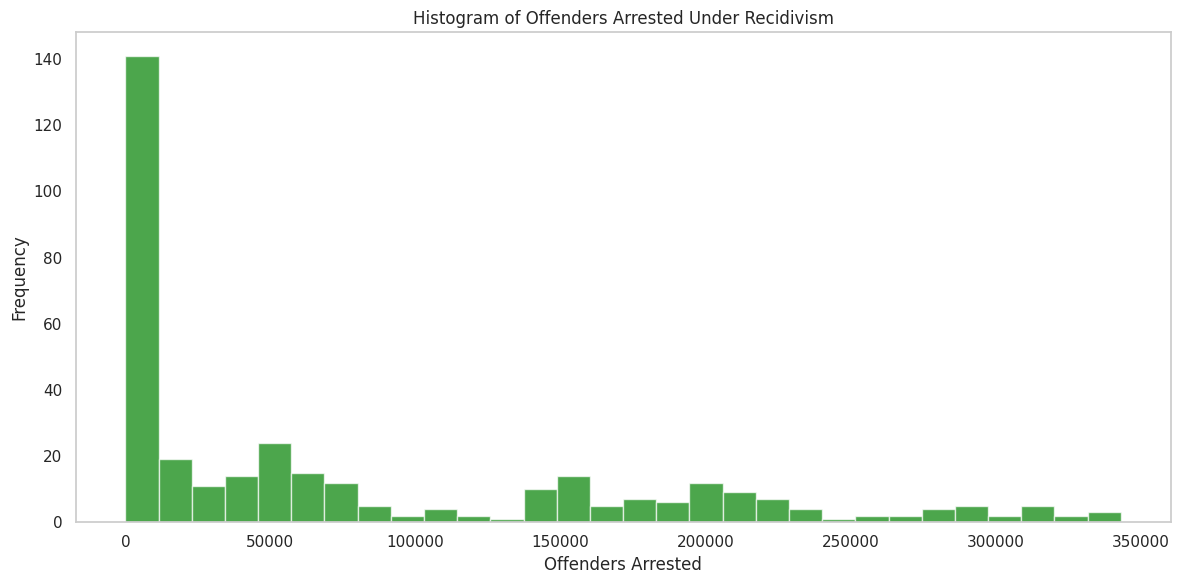

In [ ]:
# Load the specific CSV file for recidivism
file_path = '/content/Consolidated_Crime_Data/22_Persons_arrested_under_recidivism.csv'
df_recidivism = pd.read_csv(file_path)

# Remove rows with NaN values in the 'Offenders_Arrested' column
df_recidivism = df_recidivism.dropna(subset=['Offenders_Arrested'])

# Create a histogram for the 'Offenders_Arrested' column
plt.figure(figsize=(12, 6))
plt.hist(df_recidivism['Offenders_Arrested'], bins=30, color='green', alpha=0.7)
plt.title('Histogram of Offenders Arrested Under Recidivism')
plt.xlabel('Offenders Arrested')
plt.ylabel('Frequency')
plt.grid()

# Show the plot
plt.tight_layout()
plt.show()


# Correlation Matrix

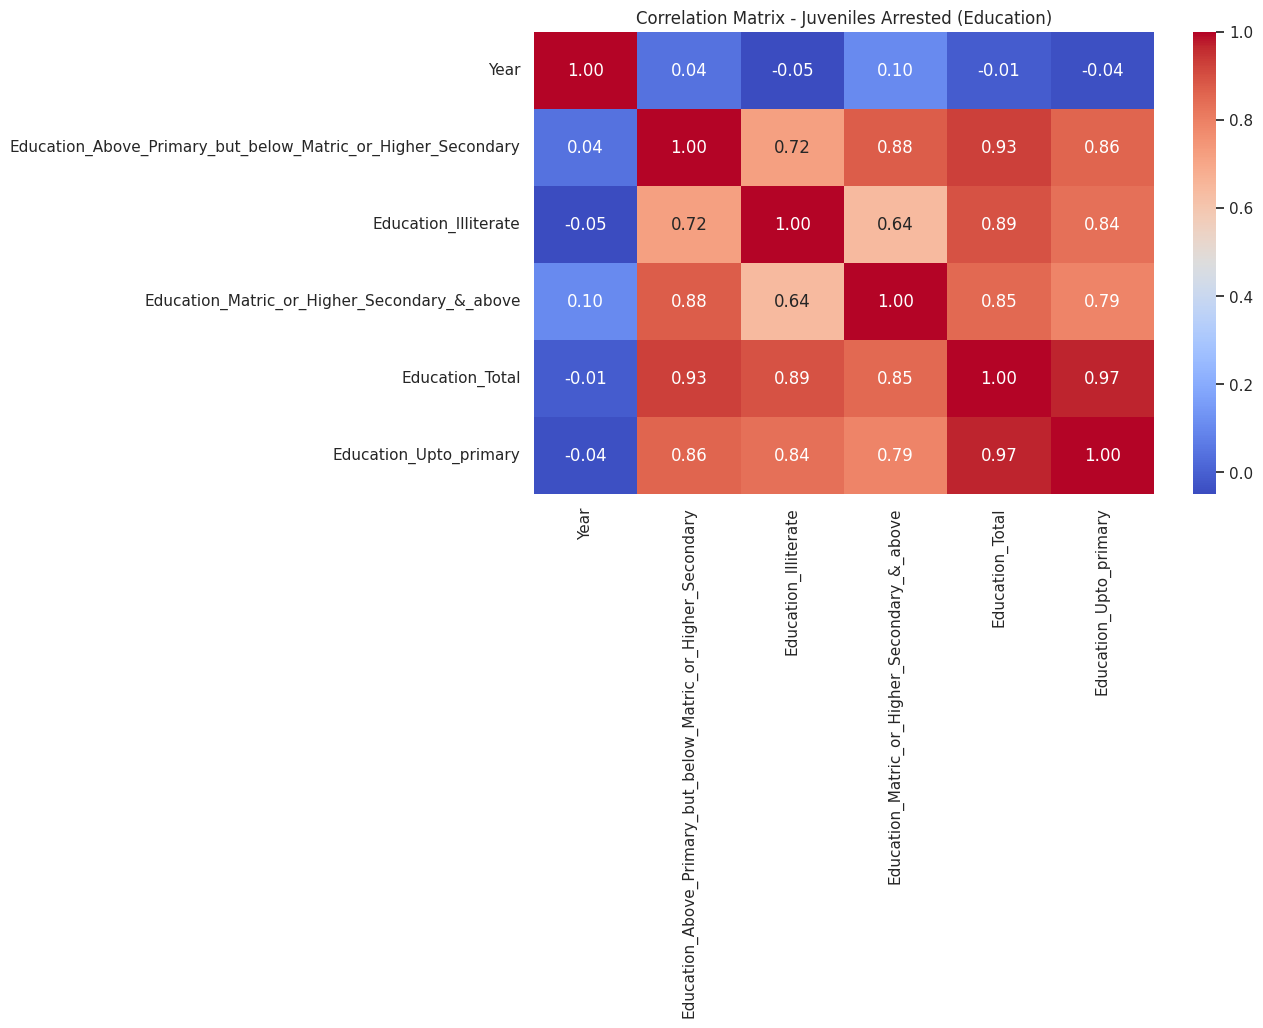

In [ ]:
# Load the CSV file
file_path_18_01 = '/content/Consolidated_Crime_Data/18_01_Juveniles_arrested_Education.csv'
df_18_01 = pd.read_csv(file_path_18_01)

# Filter only numeric columns for correlation
numeric_df_18_01 = df_18_01.select_dtypes(include=[np.number])

# Calculate the correlation matrix
correlation_matrix_18_01 = numeric_df_18_01.corr()

# Visualize the correlation matrix
plt.figure(figsize=(10, 6))
plt.title('Correlation Matrix - Juveniles Arrested (Education)')
sns.heatmap(correlation_matrix_18_01, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()


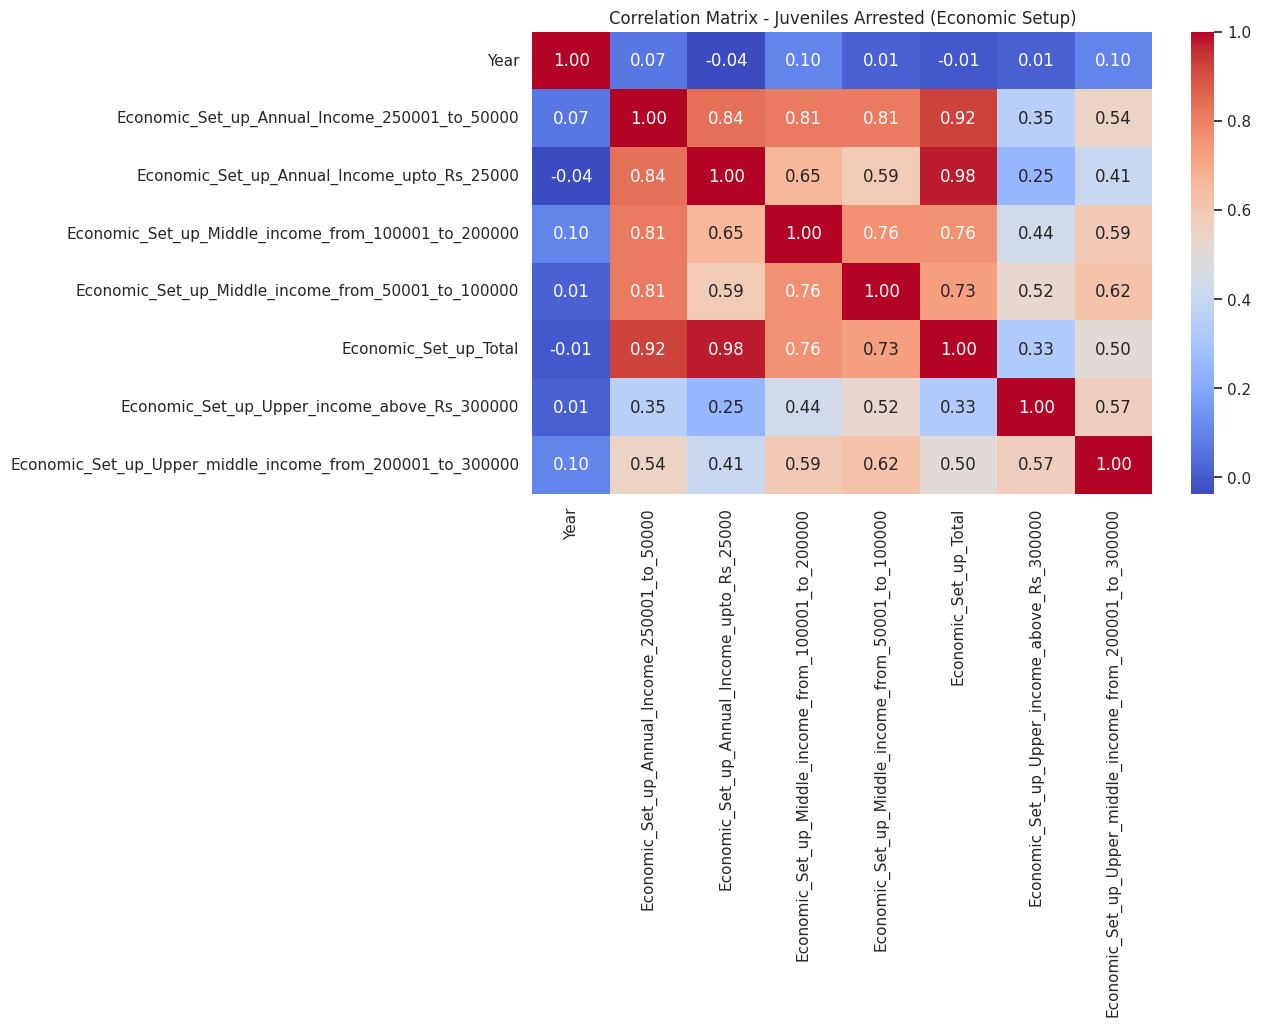

In [ ]:
# Load the CSV file
file_path_18_02 = '/content/Consolidated_Crime_Data/18_02_Juveniles_arrested_Economic_setup.csv'
df_18_02 = pd.read_csv(file_path_18_02)

# Filter only numeric columns for correlation
numeric_df_18_02 = df_18_02.select_dtypes(include=[np.number])

# Calculate the correlation matrix
correlation_matrix_18_02 = numeric_df_18_02.corr()

# Visualize the correlation matrix
plt.figure(figsize=(10, 6))
plt.title('Correlation Matrix - Juveniles Arrested (Economic Setup)')
sns.heatmap(correlation_matrix_18_02, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()


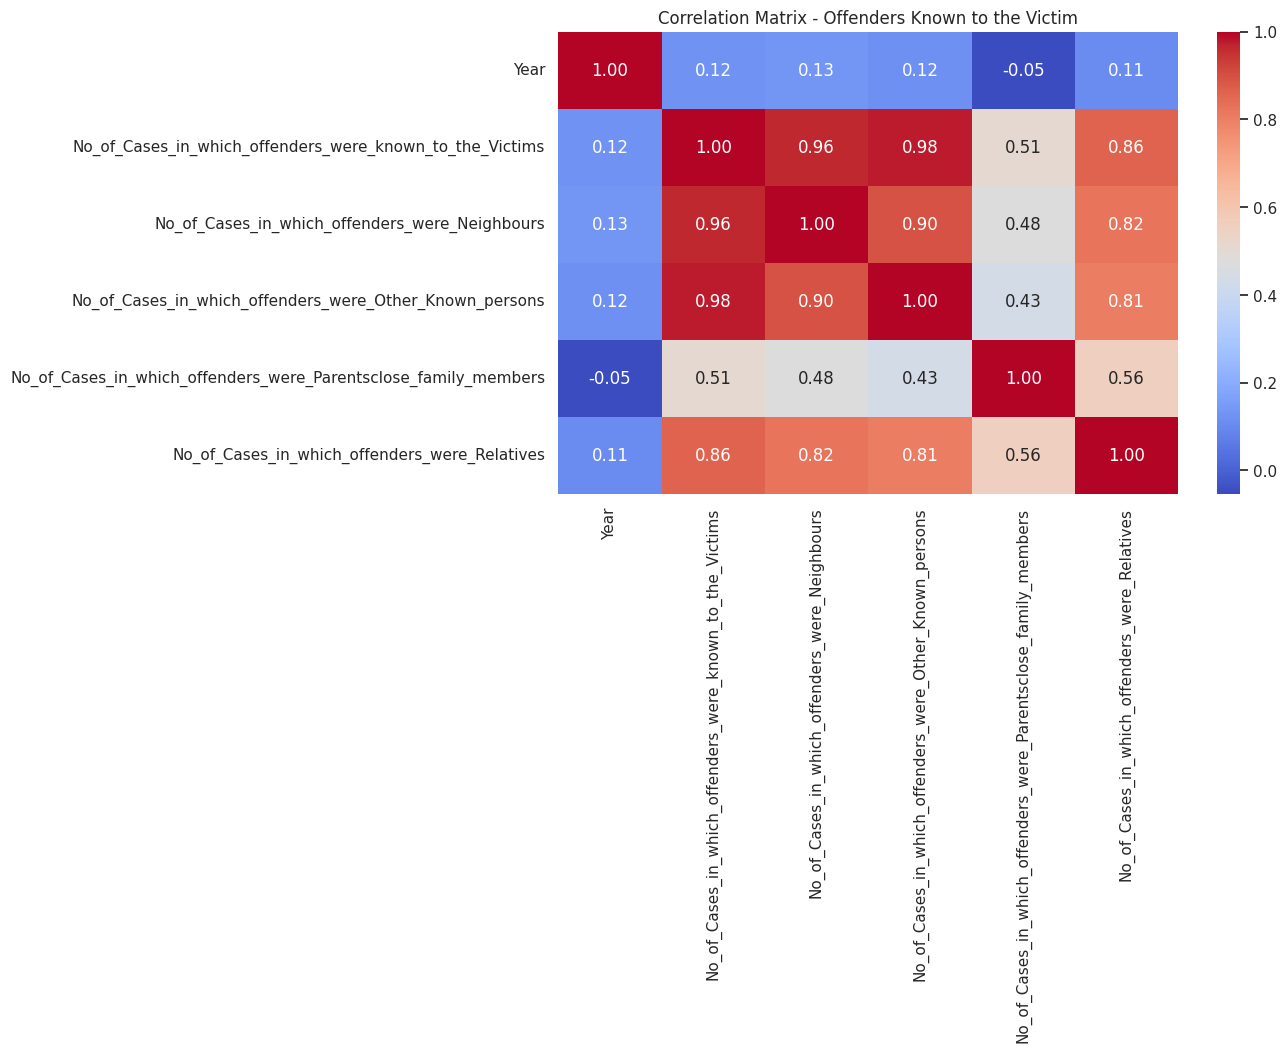

In [ ]:
# Load the CSV file
file_path_21 = '/content/Consolidated_Crime_Data/21_Offenders_known_to_the_victim.csv'
df_21 = pd.read_csv(file_path_21)

# Filter only numeric columns for correlation
numeric_df_21 = df_21.select_dtypes(include=[np.number])

# Calculate the correlation matrix
correlation_matrix_21 = numeric_df_21.corr()

# Visualize the correlation matrix
plt.figure(figsize=(10, 6))
plt.title('Correlation Matrix - Offenders Known to the Victim')
sns.heatmap(correlation_matrix_21, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()


# Boxplot

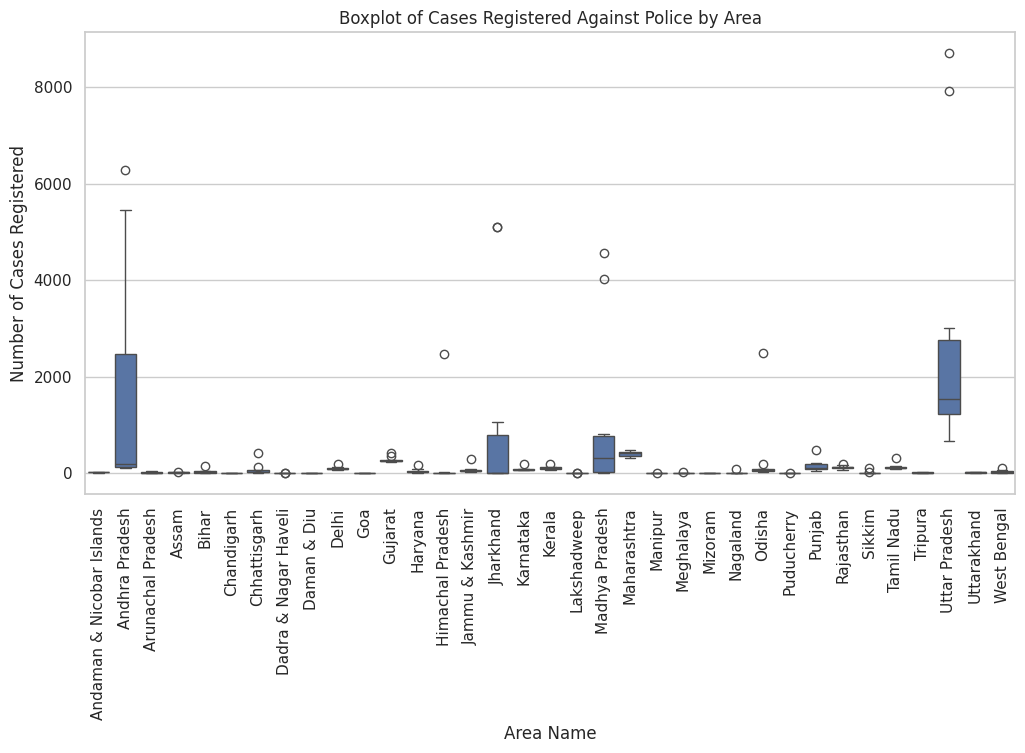

In [ ]:
# Load the Complaints Against Police Personnel dataset
df_complaints = pd.read_csv('/content/Consolidated_Crime_Data/25_Complaints_against_police.csv')

# Create a boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_complaints, x='Area_Name', y='CPA_-_Cases_Registered')
plt.title('Boxplot of Cases Registered Against Police by Area')
plt.xlabel('Area Name')
plt.ylabel('Number of Cases Registered')
plt.xticks(rotation=90)  # Rotate x-axis labels for better visibility
plt.show()



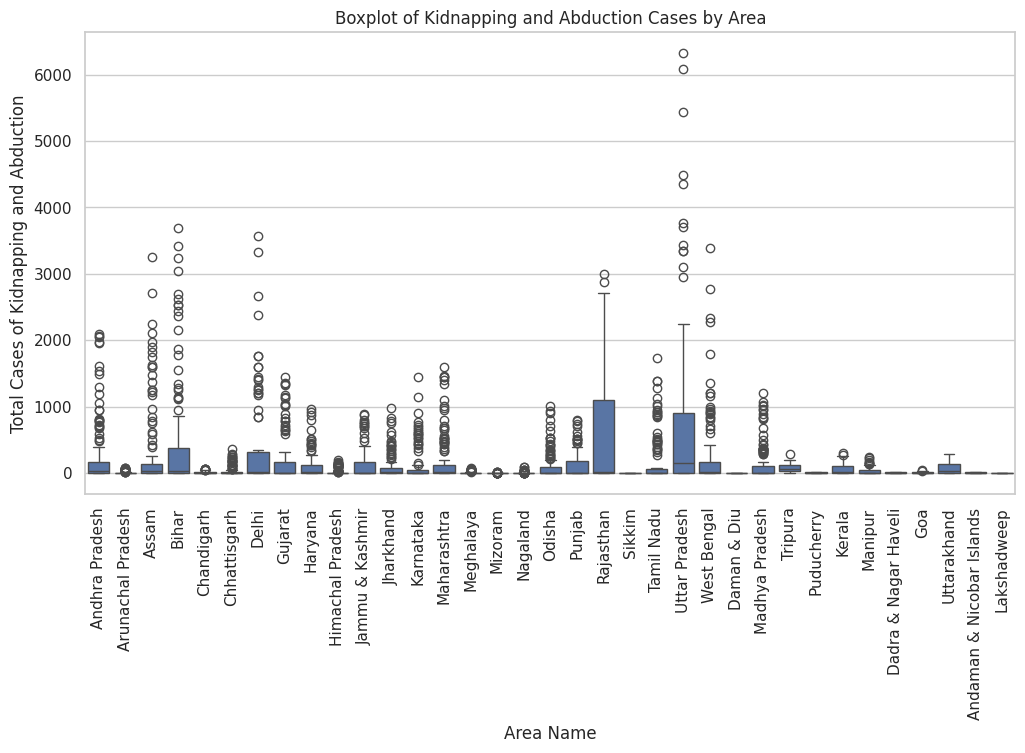

In [ ]:
# Load the dataset
df_kidnapping = pd.read_csv('/content/Consolidated_Crime_Data/39_Specific_purpose_of_kidnapping_and_abduction.csv')

# Create a boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_kidnapping, x='Area_Name', y='K_A_Grand_Total')  # Update these names as needed
plt.title('Boxplot of Kidnapping and Abduction Cases by Area')
plt.xlabel('Area Name')
plt.ylabel('Total Cases of Kidnapping and Abduction')
plt.xticks(rotation=90)  # Rotate x-axis labels for better visibility
plt.show()


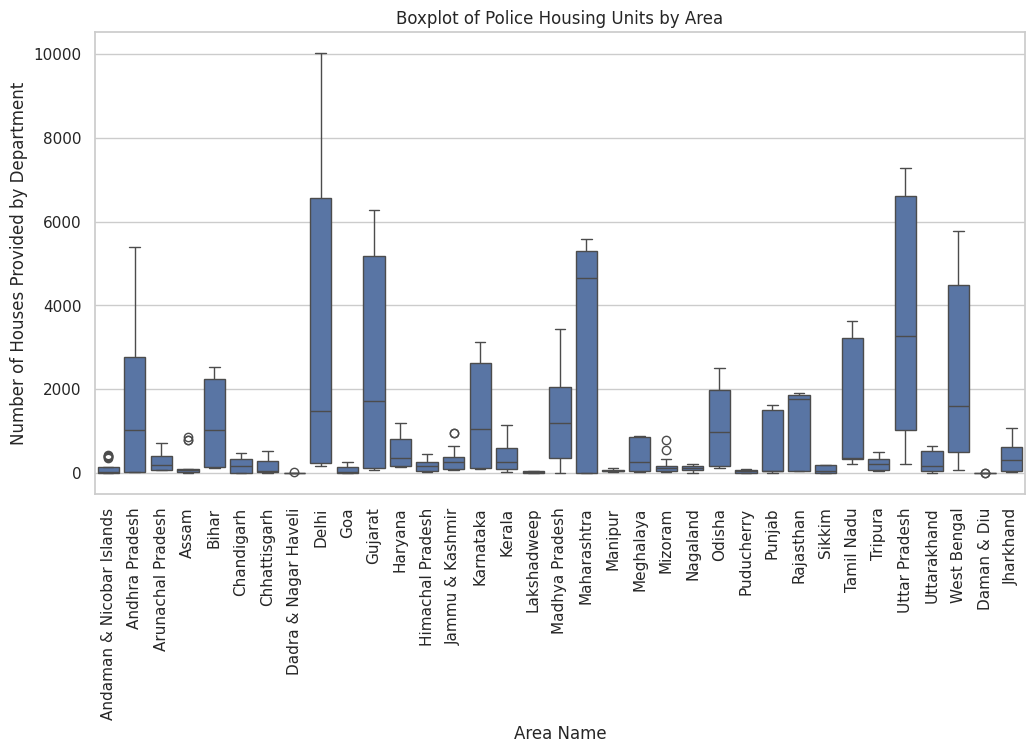

In [ ]:
# Load the dataset, skipping bad lines
df_police_housing = pd.read_csv('/content/Consolidated_Crime_Data/36_Police_housing.csv', on_bad_lines='skip')

# Create a boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_police_housing, x='Area_Name', y='PH_Houses_Provided_by_Department')
plt.title('Boxplot of Police Housing Units by Area')
plt.xlabel('Area Name')
plt.ylabel('Number of Houses Provided by Department')
plt.xticks(rotation=90)  # Rotate x-axis labels for better visibility
plt.show()


## PCA, LDA, and T-SNE

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4188 entries, 0 to 4187
Data columns (total 16 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Area_Name                           4188 non-null   object
 1   Year                                4188 non-null   int64 
 2   Group_Name                          4188 non-null   object
 3   Sub_Group_Name                      4188 non-null   object
 4   Rank_All_Ranks_Total                4188 non-null   int64 
 5   Rank_ASI_Equivalent                 4188 non-null   int64 
 6   Rank_ASPDySPAssttCommandant         4188 non-null   int64 
 7   Rank_Below_HC_and_Above_Constables  4188 non-null   int64 
 8   Rank_Constables                     4188 non-null   int64 
 9   Rank_DGAddl_DG                      4188 non-null   int64 
 10  Rank_DIG                            4188 non-null   int64 
 11  Rank_Head_Constables                4188 non-null   int6

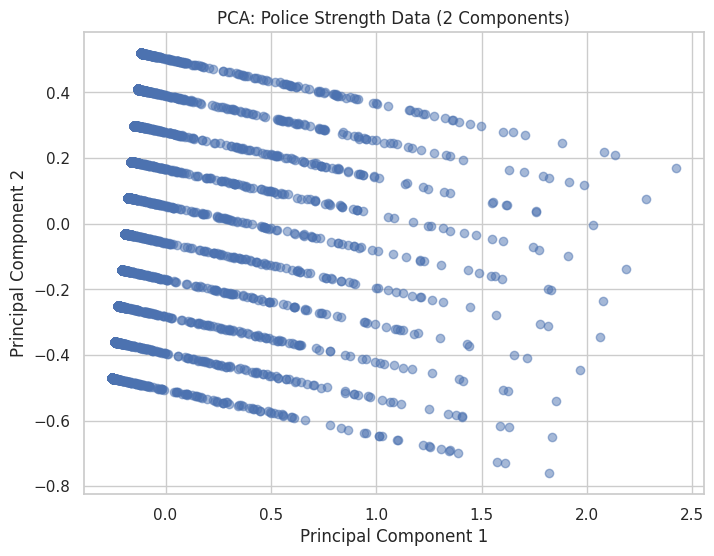

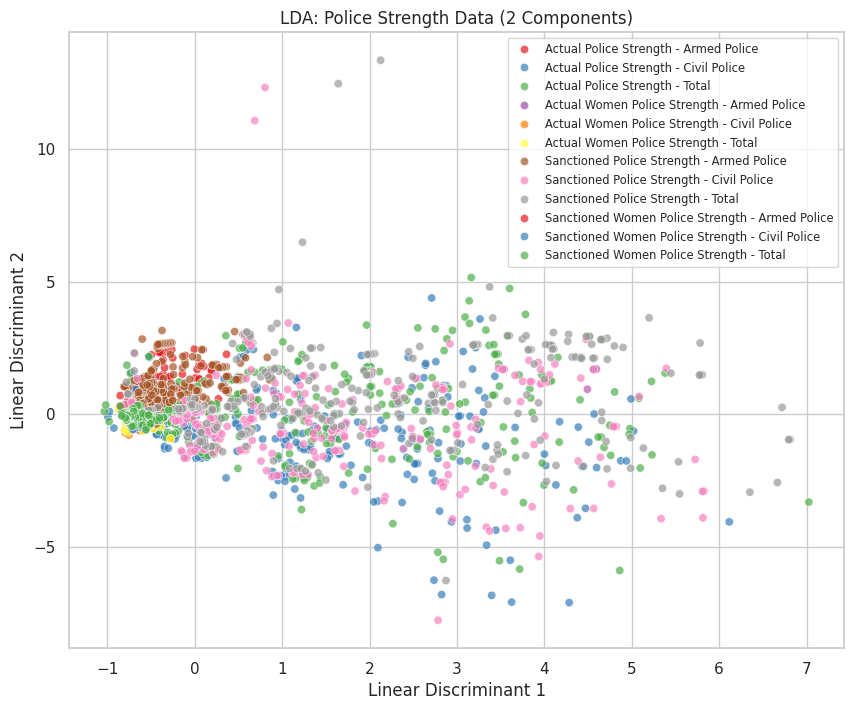

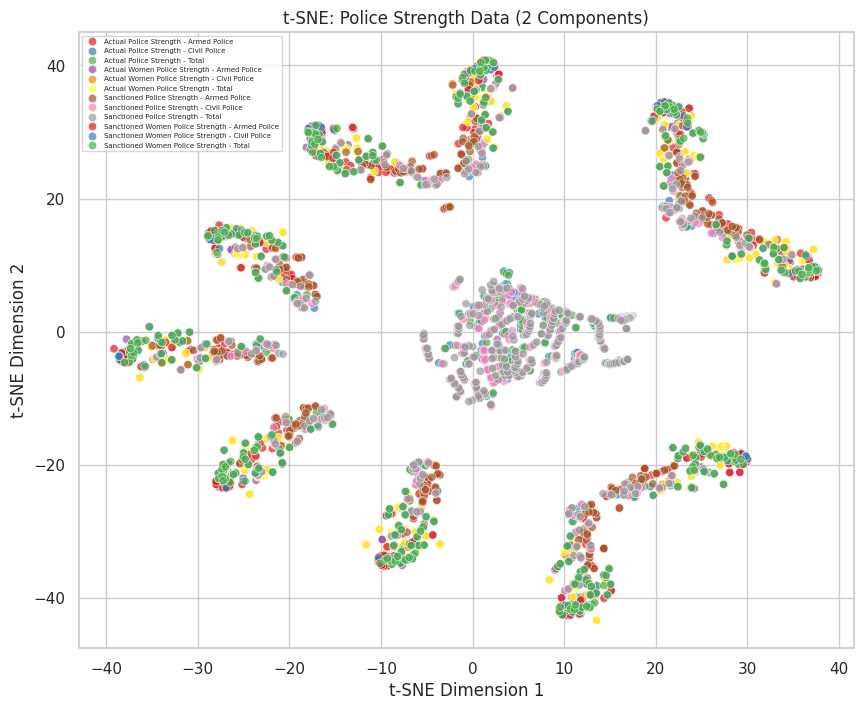

In [ ]:
# Load the data for '12_Police_strength_actual_and_sanctioned.csv'
file_path = '/content/Consolidated_Crime_Data/12_Police_strength_actual_and_sanctioned.csv'  # Update with the correct path

df_police_strength = pd.read_csv(file_path)

# Display the first few rows of the dataframe to understand its structure
df_police_strength.head()

# Check for missing values and data types
df_police_strength.info()

# If necessary, describe the numerical columns
df_police_strength.describe()

# Selecting the numerical columns (Ranks) for PCA, LDA, and t-SNE
numerical_columns = df_police_strength.select_dtypes(include=[np.number]).columns.tolist()

# Scaling the numerical columns
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_police_strength[numerical_columns])

# Create a DataFrame with scaled data for better clarity
scaled_df = pd.DataFrame(scaled_data, columns=numerical_columns)

# Display the scaled data
scaled_df.head()

# Apply PCA to reduce dimensions to 2 components
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_df)

# Create a DataFrame with the principal components
pca_df = pd.DataFrame(data=pca_components, columns=['PC1', 'PC2'])

# Plot the results
plt.figure(figsize=(8,6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.5)
plt.title('PCA: Police Strength Data (2 Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

# Define the target variable (Group_Name in this case)
target = df_police_strength['Group_Name']

# Apply LDA to reduce dimensions to 2 components
lda = LinearDiscriminantAnalysis(n_components=2)
lda_components = lda.fit_transform(scaled_df, target)

# Create a DataFrame with the LDA components and the target variable
lda_df = pd.DataFrame(data=lda_components, columns=['LD1', 'LD2'])
lda_df['Group_Name'] = target

# Plot the LDA results with Seaborn to visualize the different groups
plt.figure(figsize=(10,8))
sns.scatterplot(x='LD1', y='LD2', hue='Group_Name', data=lda_df, palette='Set1', alpha=0.7)
plt.title('LDA: Police Strength Data (2 Components)')
plt.xlabel('Linear Discriminant 1')
plt.ylabel('Linear Discriminant 2')
plt.grid(True)

# Move the legend to the upper-right corner and make it smaller
plt.legend(loc='upper right', fontsize='x-small', title_fontsize='x-small')  # Use 'x-small' for even smaller font size
plt.show()

# Apply t-SNE to reduce dimensions to 2 components
tsne = TSNE(n_components=2, random_state=33, perplexity=100)
tsne_components = tsne.fit_transform(scaled_df)

# Create a DataFrame with the t-SNE components and the target variable
tsne_df = pd.DataFrame(data=tsne_components, columns=['t-SNE1', 't-SNE2'])
tsne_df['Group_Name'] = df_police_strength['Group_Name']

# Plot the t-SNE results with Seaborn to visualize the reduction
plt.figure(figsize=(10,8))
sns.scatterplot(x='t-SNE1', y='t-SNE2', hue='Group_Name', data=tsne_df, palette='Set1', alpha=0.7)
plt.title('t-SNE: Police Strength Data (2 Components)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True)

# Move the legend to the upper-left corner and make it smaller
plt.legend(loc='upper left', fontsize= 5 , title_fontsize= 5)
plt.show()


# Clustering Algorithms (Iterative, Hierarchical, Density, Probability)

Missing values:
 Area_Name                   0
Year                        0
Group_Name                  0
Sub_Group_Name              0
Victims_Above_50_Yrs       56
Victims_Total               0
Victims_Upto_10_15_Yrs    142
Victims_Upto_10_Yrs       118
Victims_Upto_15_18_Yrs    130
Victims_Upto_18_30_Yrs      9
Victims_Upto_30_50_Yrs     11
dtype: int64


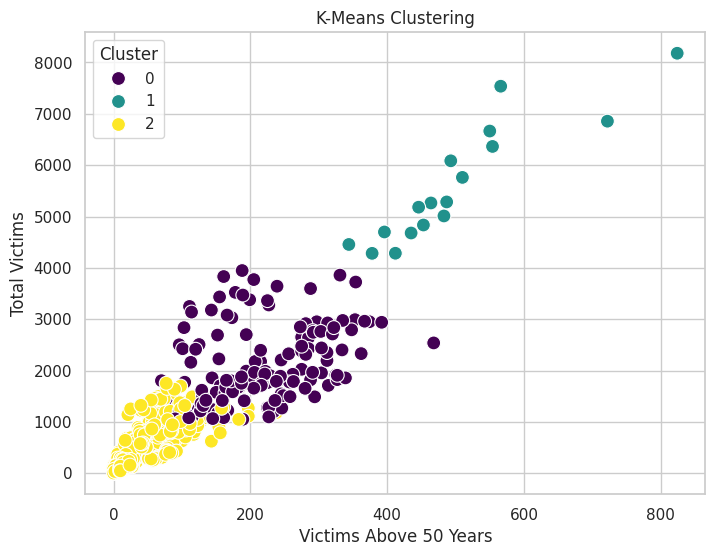

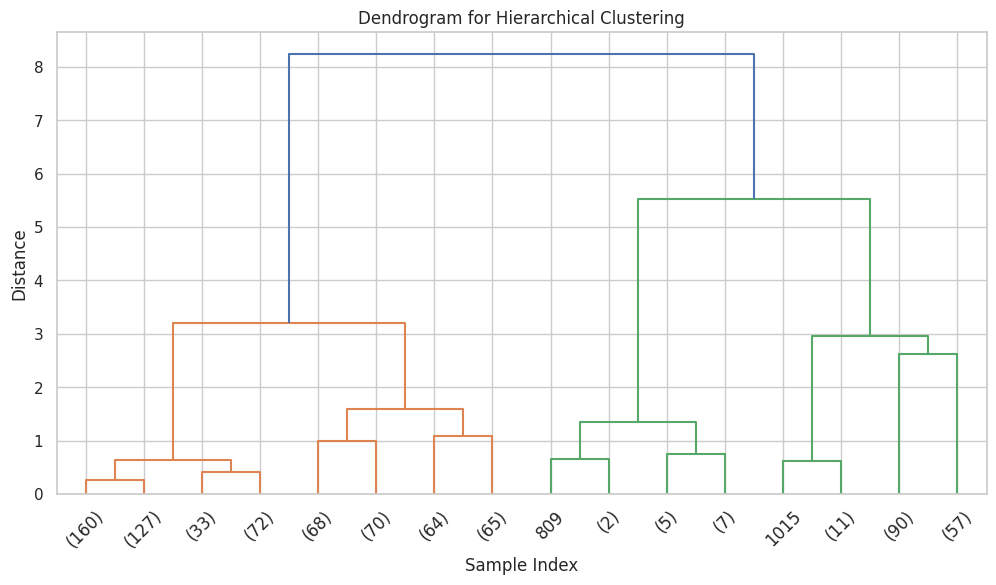

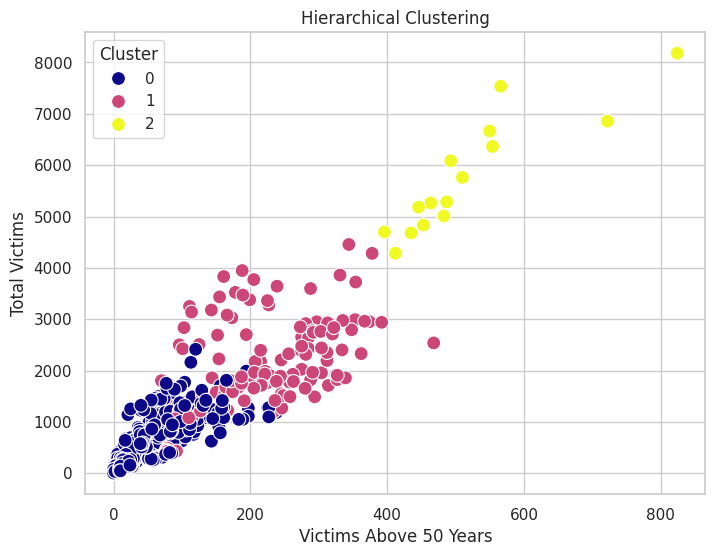

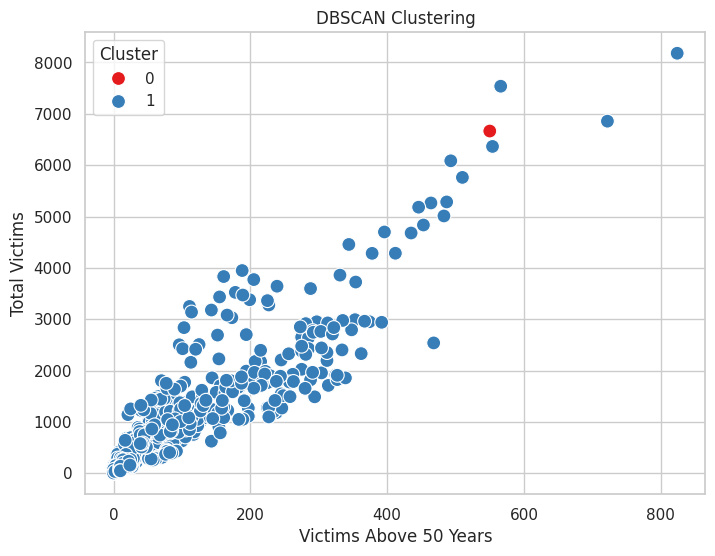

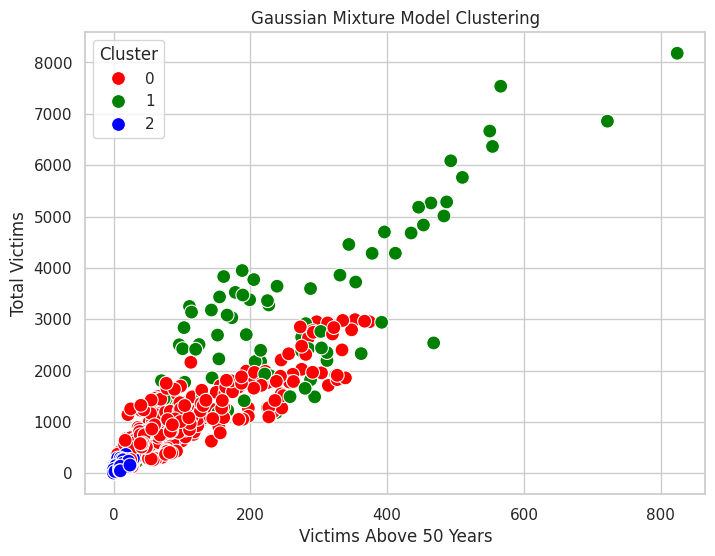

In [ ]:
# Load the dataset
file_path = 'Consolidated_Crime_Data/32_Murder_victim_age_sex.csv'
data = pd.read_csv(file_path)

# Check for missing values
missing_values = data.isnull().sum()
print("Missing values:\n", missing_values)

# Drop rows with missing values
data = data.dropna()

# Select relevant features for clustering
features = data[['Victims_Above_50_Yrs', 'Victims_Upto_10_15_Yrs',
                 'Victims_Upto_10_Yrs', 'Victims_Upto_15_18_Yrs',
                 'Victims_Upto_18_30_Yrs', 'Victims_Upto_30_50_Yrs']]

# Scale the features
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(features)

# 1. K-Means Clustering (Iterative)
kmeans = KMeans(n_clusters=3, random_state=33)  # Adjust n_clusters as needed
data['KMeans_Cluster'] = kmeans.fit_predict(scaled_features)

# Visualize K-Means Clustering
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data['Victims_Above_50_Yrs'], y=data['Victims_Total'],
                hue=data['KMeans_Cluster'], palette='viridis', s=100)
plt.title('K-Means Clustering')
plt.xlabel('Victims Above 50 Years')
plt.ylabel('Total Victims')
plt.legend(title='Cluster')
plt.show()

# 2. Hierarchical Clustering
# Create a dendrogram with custom x-axis labels
plt.figure(figsize=(12, 6))
dendrogram = sch.dendrogram(
    sch.linkage(scaled_features, method='ward'),
    labels=data.index.astype(str),  # Use the index as labels for better context
    truncate_mode='level', p=3  # Truncate to show fewer levels
)
plt.title('Dendrogram for Hierarchical Clustering')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.xticks(rotation=45)  # Rotate x-axis labels for better visibility
plt.show()

# Fit Hierarchical Clustering
from sklearn.cluster import AgglomerativeClustering
hierarchical = AgglomerativeClustering(n_clusters=3)  # Adjust n_clusters as needed
data['Hierarchical_Cluster'] = hierarchical.fit_predict(scaled_features)

# Visualize Hierarchical Clustering
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data['Victims_Above_50_Yrs'], y=data['Victims_Total'],
                hue=data['Hierarchical_Cluster'], palette='plasma', s=100)
plt.title('Hierarchical Clustering')
plt.xlabel('Victims Above 50 Years')
plt.ylabel('Total Victims')
plt.legend(title='Cluster')
plt.show()

# 3. DBSCAN (Density-Based Clustering)
dbscan = DBSCAN(eps=0.5, min_samples=5)  # Adjust parameters as needed
data['DBSCAN_Cluster'] = dbscan.fit_predict(scaled_features)

# Replace -1 (noise) with a distinct cluster number
data['DBSCAN_Cluster'] = data['DBSCAN_Cluster'].apply(lambda x: x + 1 if x != -1 else 0)

# Visualize DBSCAN Clustering
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data['Victims_Above_50_Yrs'], y=data['Victims_Total'],
                hue=data['DBSCAN_Cluster'], palette='Set1', s=100)
plt.title('DBSCAN Clustering')
plt.xlabel('Victims Above 50 Years')
plt.ylabel('Total Victims')
plt.legend(title='Cluster')
plt.show()

# 4. Gaussian Mixture Model (Probability-Based)
gmm = GaussianMixture(n_components=3, random_state=33)  # Adjust n_components as needed
data['GMM_Cluster'] = gmm.fit_predict(scaled_features)

# Visualize GMM Clustering with distinct colors
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data['Victims_Above_50_Yrs'], y=data['Victims_Total'],
                hue=data['GMM_Cluster'], palette=['red', 'green', 'blue'], s=100)
plt.title('Gaussian Mixture Model Clustering')
plt.xlabel('Victims Above 50 Years')
plt.ylabel('Total Victims')
plt.legend(title='Cluster')
plt.show()
